# Get all data needed

### Setup

In [2]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from entsoe import mappings, EntsoePandasClient
from entsoe.geo.utils import load_zones
import contextily as ctx

import pandas as pd
from retry_requests import retry
import os
import matplotlib.pyplot as plt
import warnings
import requests
from pandas import json_normalize
import geopandas as gpd
import shapely
import xarray as xr
import glob


from scripts.utils import read_file, scale_font_latex
from scripts.countries import GEN_COLUMN_MAP, GEN_COLUMN_MAP_ALT, EUROPEAN_BZN
from scripts.config import *
from scripts.constants import *
%load_ext autoreload
%autoreload 2

### Create folders

In [2]:
# Create necessary directories
os.makedirs("../data", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/intermediate", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

### configuration

In [ ]:
# .env path

dotenv_path = f"../.env.txt"


# load up the entries as environment variables

load_dotenv(dotenv_path)


api_key_entsoe = os.environ.get("api_key_entsoe")

client = EntsoePandasClient(api_key=api_key_entsoe, retry_count=30, retry_delay=30)


# Neighbours

NEIGHBOURS = mappings.NEIGHBOURS

neighbours = [cc for cc in NEIGHBOURS["FR"] if cc not in ["GB", "IT_NORD_FR", "CH"]] + [
    cc for cc in NEIGHBOURS["ES"] if cc not in ["GB", "IT_NORD_FR", "CH"]
]

print(neighbours)


def fixed_chunks(start, end, chunk_days=30, beyond_year=False):
    """
    Splits time between start and end into chunks of defined length.
    """
    chunks = []
    current_start = start

    while current_start < end:
        chunk_start = current_start
        year_end = pd.Timestamp(
            year=current_start.year, month=12, day=31, hour=23, tz=current_start.tz
        )
        # 23h of the last day of the month
        chunk_end = (
            chunk_start + pd.Timedelta(days=chunk_days)
        ).normalize() - pd.Timedelta(hours=1)
        if beyond_year:
            chunk_end = min(chunk_end, end)
        else:
            chunk_end = min(chunk_end, year_end, end)

        chunks.append((chunk_start, chunk_end))

        current_start = chunk_end + pd.Timedelta(hours=1)
    return chunks


def chunk_query(
    client,
    method,
    country_code,
    start,
    end,
    chunk_days=400,
    beyond_year=False,
    **kwargs,
):
    """
    Splits longer queries from start to end into monthly queries to avoid API limitations.
    """

    temp = True
    df_chunks = []
    next_chunk_days = {chunk_days: 120, 120: 90, 90: 60, 60: 30, 30: 10, 10: 7, 7: 1}
    while temp:
        chunks = fixed_chunks(start, end, chunk_days, beyond_year=beyond_year)
        for chunk_start, chunk_end in chunks:
            print(chunk_start, chunk_end)
            try:
                df_chunk = method(
                    country_code, start=chunk_start, end=chunk_end, **kwargs
                )
                df_chunks.append(df_chunk)
                temp = False
            except Exception as e:
                print(
                    f"Query failed in chunk: {chunk_start} - {chunk_end} with error {e} and chunks of {chunk_days}"
                )
                if e.response.status_code == 400:
                    print("No data available, continuing with empty frame.")
                    df_chunk = pd.DataFrame()
                elif chunk_days != 1:
                    chunk_days = next_chunk_days[chunk_days]
                    start = chunk_start
                    temp = True
                    break
                else:
                    print("Problems with query. Data retrival failed.")
                    return None

    return pd.concat(df_chunks).sort_index()


def adjust_de_bzn_split(df, start, end, time_of_split):
    """

    Adjusts the bidding zone split for Germany (DE_LU and DE_AT_LU) in the given DataFrame.


    Parameters:

    - df (pd.DataFrame): The DataFrame containing the data to adjust.

    - start (pd.Timestamp): The start timestamp of the data.

    - end (pd.Timestamp): The end timestamp of the data.

    - time_of_split (pd.Timestamp): The timestamp when the bidding zone split occurred.


    Returns:

    - pd.DataFrame: The adjusted DataFrame with the DE_LU column updated and DE_AT_LU removed.
    """

    df.loc[start:time_of_split, "DE_LU"] = df.loc[start:time_of_split, "DE_LU"].fillna(
        0
    )

    df.loc[time_of_split:end, "DE_AT_LU"] = df.loc[
        time_of_split:end, "DE_AT_LU"
    ].fillna(0)

    df["DE_LU"] += df["DE_AT_LU"]

    df = df.drop("DE_AT_LU", axis=1)

    return df

### Nuclear availability

In [4]:
def get_nuclear_capacity(path_2018_2020, path_2021_2023):

    installed_capacity_2018_2020 = pd.read_csv(path_2018_2020)

    installed_capacity_2021_2023 = pd.read_csv(path_2021_2023)

    installed_capacity = pd.concat(
        [installed_capacity_2018_2020, installed_capacity_2021_2023], axis=0
    )

    # print(installed_capacity.columns)

    installed_capacity = installed_capacity.pivot_table(
        index="Year",
        columns="Production Type",
        values="Installed Capacity (MW)",
        aggfunc="first",
    )

    installed_capacity = installed_capacity.loc[START.year : END.year, :]

    # Replace 'n/e' with NaN

    installed_capacity.replace("n/e", 0, inplace=True)

    # Convert to hourly

    # get hourly timestamp index

    # Extract all unique years

    years = list(range(pd.to_datetime(START).year, pd.to_datetime(END).year + 1))

    # Convert to a Pandas DateTime index (Optional)

    index = pd.to_datetime([f"{year}-01-01" for year in years], utc=True)

    installed_capacity.index = index

    installed_capacity = installed_capacity.resample("1h").ffill()

    # Create a new index for the remaining part of the year (hourly)

    remaining_start = installed_capacity.index[-1] + pd.DateOffset(
        hours=1
    )  # Start the next day after the last year

    remaining_end = END

    # Create an hourly timestamp index for the remaining year

    remaining_index = pd.date_range(start=remaining_start, end=remaining_end, freq="h")

    # Create a DataFrame with the remaining hourly index

    remaining_data = pd.DataFrame(index=remaining_index)

    # Concatenate the existing data with the new hourly DataFrame

    installed_capacity = pd.concat([installed_capacity, remaining_data])

    installed_capacity.ffill(inplace=True)

    # select only necessary data and convert to int df

    nuclear_cap = pd.DataFrame(installed_capacity.loc[START:END, "Nuclear"]).astype(
        float
    )

    nuclear_cap = nuclear_cap.rename(columns={"Nuclear": "nuclear_cap"})

    nuclear_cap.index.name = "timestamp"
    return nuclear_cap

In [ ]:
def get_nuclear_unavail_rte(path_rte, save_path):
    nuclear_cap = get_nuclear_capacity(
        paths["installed_cap_raw_FR_2018_2020"],
        paths["installed_cap_raw_FR_2021_2023"],
    )

    gen_unavail_rte = pd.read_csv(path_rte)

    gen_unavail_rte = gen_unavail_rte[
        [
            "Publication Date/Time (UTC)",
            "Unavailable Capacity",
            "Event Start (UTC)",
            "Event Stop (UTC)",
            "Affected Asset or Unit EIC Code",
            "Type of Unavailability",
            "Event Status",
            "Affected Asset or Unit",
        ]
    ].sort_values(by="Event Start (UTC)")

    # RTE retrieval
    df_unavail_rte = pd.DataFrame(
        0,
        columns=["nuclear_unavail", "nuclear_unavail_unplanned"],
        index=pd.date_range(start=START, end=END, freq="h"),
    )
    df_data_nuclear = gen_unavail_rte[
        gen_unavail_rte["Event Status"] != "Dismissed"
    ].drop_duplicates()

    df_data_nuclear["start"] = pd.to_datetime(
        df_data_nuclear["Event Start (UTC)"], utc=True
    )
    df_data_nuclear["end"] = pd.to_datetime(
        df_data_nuclear["Event Stop (UTC)"], utc=True
    )

    # for every entry in df_data_nuclear:
    # create timeframe for unavail capacity = nominal power - avail_qty
    for i in range(len(df_data_nuclear)):
        unavail = df_data_nuclear.iloc[i]
        df_tmp = pd.DataFrame(columns=["tmp"])
        df_tmp.loc[unavail["start"].replace(minute=0)] = unavail["Unavailable Capacity"]
        df_tmp.loc[unavail["end"].replace(minute=0)] = unavail["Unavailable Capacity"]
        df_tmp = df_tmp.resample("1h").ffill()

        df_tmp = df_tmp.iloc[:-1]  # dropping last row since end time should excluded

        # only include unplanned outages if longer than 24h -> otherwise should not effect da price.
        if (unavail["Type of Unavailability"] == "Unplanned") and (len(df_tmp) < 24):
            df_unavail_rte["nuclear_unavail_unplanned"] = df_unavail_rte[
                "nuclear_unavail_unplanned"
            ].add(df_tmp["tmp"], fill_value=0)
            continue

        if len(df_tmp) > 2:
            df_unavail_rte = df_unavail_rte.join(df_tmp)

            df_unavail_rte["nuclear_unavail"] = df_unavail_rte["nuclear_unavail"].add(
                df_unavail_rte["tmp"], fill_value=0
            )
            df_unavail_rte["nuclear_unavail_unplanned"] = df_unavail_rte[
                "nuclear_unavail_unplanned"
            ].add(df_tmp["tmp"], fill_value=0)
            df_unavail_rte.drop(columns=["tmp"], inplace=True)

    # nuclear availability = installed capacity - unavailable capacity
    df_nuclear_avail = df_unavail_rte.join(nuclear_cap)
    df_nuclear_avail["nuclear_avail"] = df_nuclear_avail["nuclear_cap"].sub(
        df_nuclear_avail["nuclear_unavail"]
    )
    df_nuclear_avail["nuclear_avail_unplanned"] = df_nuclear_avail["nuclear_cap"].sub(
        df_nuclear_avail["nuclear_unavail_unplanned"]
    )

    # Limit to time frame and save
    df_nuclear_avail.index.rename("timestamp", inplace=True)
    df_nuclear_avail.truncate(before=START, after=END)
    df_nuclear_avail.to_csv(save_path)


get_nuclear_unavail_rte(paths["na_gen_unavail_rte_raw_FR"], paths["na_rte_FR"])

In [6]:
def get_nuclear_avail_esia(path_esia, save_path):
    gen_nuclear_avail_esia = pd.read_csv(path_esia, sep=";")
    gen_nuclear_avail_esia = gen_nuclear_avail_esia[["value", "datetime"]]
    gen_nuclear_avail_esia.rename(
        columns={"value": "nuclear_avail", "datetime": "timestamp"}, inplace=True
    )
    gen_nuclear_avail_esia["timestamp"] = pd.to_datetime(
        gen_nuclear_avail_esia["timestamp"], utc=True
    )
    gen_nuclear_avail_esia.set_index("timestamp", inplace=True)
    gen_nuclear_avail_esia = gen_nuclear_avail_esia.truncate(before=START, after=END)
    gen_nuclear_avail_esia.to_csv(save_path)


get_nuclear_avail_esia(
    paths["na_gen_unavail_esios_raw_ES"],
    paths["na_esios_ES"],
)

### renewables, load, generation

In [ ]:
for country_code in [
    "FR",
    "ES",
]:

    try:

        start = START - pd.Timedelta(days=2)

        end = QUERY_END

        print("renewable da")

        renewable_da = (
            client.query_wind_and_solar_forecast(
                country_code, start=start, end=end, psr_type=None
            )
            .tz_convert(tz="utc")
            .rename(
                columns={
                    "Unnamed: 0": "timestamp",
                    "Solar": "solar_da",
                    "Wind Offshore": "wind_off_da",
                    "Wind Onshore": "wind_on_da",
                }
            )
        )

        renewable_da.index.name = "timestamp"

        print("load da")

        load_da = (
            client.query_load_forecast(country_code, start=start, end=end)
            .tz_convert(tz="utc")
            .rename(columns={"Unnamed: 0": "timestamp", "Forecasted Load": "load_da"})
        )

        load_da.index.name = "timestamp"

        print("load real")
        load_real = (
            client.query_load(country_code, start=start, end=end)
            .tz_convert(tz="utc")
            .rename(columns={"Unnamed: 0": "timestamp", "Actual Load": "load"})
        )

        load_real.index.name = "timestamp"

        print("generation")

        generation = client.query_generation(
            country_code,
            start=start,
            end=end,
        ).tz_convert(tz="utc")

    except Exception as e:

        print(e)

    renewable_da = renewable_da.truncate(before=START, after=END)

    load_da = load_da.truncate(before=START, after=END)

    load_real = load_real.truncate(before=START, after=END)

    generation = generation.truncate(before=START, after=END)

    renewable_da.to_csv(paths[f"renew_{country_code}"])

    load_da.to_csv(paths[f"load_da_{country_code}"])

    load_real.to_csv(paths[f"load_real_{country_code}"])

    generation.to_csv(paths[f"generation_{country_code}"])

### Hydro filling rate

In [ ]:
def get_hydro_filling(path_2018_2020, path_2021_2023, save_path):
    df_2018_2020 = pd.read_csv(path_2018_2020)
    df_2021_2023 = pd.read_csv(path_2021_2023)
    df = pd.concat([df_2018_2020, df_2021_2023], axis=0)

    hourly_data = {}
    for year in df["Year"].unique():
        # Extract year
        print(f"Processing year: {year}")

        # Filter out None/NaN
        df_year = df[df["Year"] == year].copy()
        df_year["Week_Num"] = df_year["Week"].str.extract(r"(\d+)").astype(int)

        weekly_series_list = []
        for i, row in df_year.iterrows():
            week_start = pd.Timestamp.fromisocalendar(year, row.Week_Num, 1)
            week_end = week_start + pd.Timedelta(
                days=6, hours=23
            )  # include full last day
            week_dates = pd.date_range(start=week_start, end=week_end, freq="h")
            week_values = pd.Series(
                [row["Energy (MWh)"]] * len(week_dates), index=week_dates
            )
            weekly_series_list.append(week_values)

        # Combine all weeks
        hourly_series = pd.concat(weekly_series_list)

        hourly_data[year] = hourly_series
    # Combine all years vertically into single column
    all_series = []
    for year, s in hourly_data.items():
        temp = s.to_frame(name="filling_rate")
        all_series.append(temp)
    # Sort by datetime index
    hourly_df = pd.concat(all_series).sort_index()
    # Convert index to UTC
    hourly_df.index = hourly_df.index.tz_localize("UTC")

    # Rename index
    hourly_df.index.name = "timestamp"
    # Limit to time frame and save
    hourly_df = hourly_df.truncate(before=START, after=END)
    hourly_df.to_csv(save_path)


get_hydro_filling(
    path_2018_2020=paths["filling_rate_raw_ES_2018_2020"],
    path_2021_2023=paths["filling_rate_raw_ES_2021_2023"],
    save_path=paths["filling_rate_ES"],
)
get_hydro_filling(
    path_2018_2020=paths["filling_rate_raw_FR_2018_2020"],
    path_2021_2023=paths["filling_rate_raw_FR_2021_2023"],
    save_path=paths["filling_rate_FR"],
)

### Residual load neighbours

In [ ]:
res_load = pd.DataFrame(index=pd.date_range(START, QUERY_END, freq="h", tz="utc"))
res_load.index.name = "timestamp"

for cc in neighbours:
    print(cc)
    try:
        start = START
        end = QUERY_END
        print("renewable da")
        renewable_da = client.query_wind_and_solar_forecast(
            cc, start=start, end=end, psr_type=None
        ).tz_convert(tz="utc")
        print(renewable_da.columns)
        renewable_da.rename(
            columns={
                "Solar": "solar_da",
                "Wind Offshore": "wind_off_da",
                "Wind Onshore": "wind_on_da",
            }
        )
        renewable_da.index.name = "timestamp"
        print("load da")
        load_da = (
            client.query_load_forecast(cc, start=start, end=end)
            .tz_convert(tz="utc")
            .rename(columns={"Unnamed: 0": "timestamp", "Forecasted Load": "load_da"})
        )
        load_da = load_da.resample("1h").mean()
        renewable_da = renewable_da.resample("1h").mean()
        rl = pd.DataFrame(
            load_da["load_da"] - renewable_da.sum(axis=1), columns=["rl_" + cc]
        )
        res_load = res_load.join(rl)
    except:
        print("error in ", cc)


# adjust for bzn split in DE LU
res_load.loc[:TIME_DE_AT_LU_SPLIT, "rl_DE_LU"] = res_load.loc[
    :TIME_DE_AT_LU_SPLIT, "rl_DE_LU"
].fillna(0)
res_load.loc[TIME_DE_AT_LU_SPLIT:, "rl_DE_AT_LU"] = res_load.loc[
    TIME_DE_AT_LU_SPLIT:, "rl_DE_AT_LU"
].fillna(0)
res_load["rl_DE_LU"] += res_load["rl_DE_AT_LU"]
res_load = res_load.drop("rl_DE_AT_LU", axis=1)
res_load.truncate(before=START, after=END)
res_load.to_csv(paths["res_load_da"])

### Get import and exports

In [14]:
def generate_year_chunks(start, end):
    chunks = []
    chunk_start = start
    while chunk_start < end:
        # Define chunk end as either 1 year later or the global END
        next_year = chunk_start + pd.DateOffset(years=1) - pd.Timedelta(days=1)
        chunk_end = min(next_year, end)
        chunks.append((chunk_start, chunk_end))
        chunk_start = chunk_end + pd.Timedelta(days=1)
    return chunks


chunks = generate_year_chunks(START, END + pd.Timedelta(days=1))  # safety puffer
# Import exports of Marocco and spain (aggregated daily values)


url_MA = "https://apidatos.ree.es/es/datos/intercambios/marruecos-frontera-programado"
url_AD = "https://apidatos.ree.es/es/datos/intercambios/andorra-frontera-programado"
df_ES_other_export = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
for country_code, url in zip(["MA", "AD"], [url_MA, url_AD]):
    data_chunks = []
    for chunk_start, chunk_end in chunks:

        params = {
            "start_date": chunk_start,
            "end_date": chunk_end,
            "time_trunc": "day",
        }

        response = requests.get(url, params=params)

        data = response.json()
        data_points = data["included"][0]["attributes"]["values"]
        for data_point in data_points:
            data_chunks.append(
                {
                    "timestamp": pd.Timestamp(data_point["datetime"]),
                    "flow_MWh": data_point["value"],
                }
            )
    df = pd.DataFrame(data_chunks)
    df.set_index("timestamp", inplace=True)
    df.sort_index(inplace=True)

    hourly_list = []

    for day, row in df.iterrows():
        # Divide daily flow equally across 24 hours
        hourly_value = row["flow_MWh"] / 24
        # Generate 24 hourly timestamps for that day
        for h in range(24):
            hourly_list.append(
                {"timestamp": day + pd.Timedelta(hours=h), country_code: hourly_value}
            )

    # Convert to DataFrame
    df_hourly = pd.DataFrame(hourly_list)
    df_hourly.sort_index(inplace=True)
    df_hourly.set_index("timestamp", inplace=True)
    df_hourly.index = pd.to_datetime(
        df_hourly.index, utc=True
    )  # converts to utc, as API already yields timezone aware data
    df_hourly = df_hourly[~df_hourly.index.duplicated(keep="first")]
    df_hourly = df_hourly.truncate(before=START, after=END)
    df_ES_other_export[country_code] = df_hourly[country_code]

In [ ]:
def get_imports_exports(country_code):
    # scheduled commercial exchange.
    # only commercial exchange was used. day ahead exchange only available after 2018.
    da_import = pd.DataFrame(index=pd.date_range(START, QUERY_END, freq="h", tz="utc"))
    da_import.index.name = "timestamp"
    da_export = da_import.copy()

    for neighbour in NEIGHBOURS[country_code]:
        print(neighbour)
        start = START
        end = QUERY_END
        try:
            # day-ahead export
            df_tmp = client.query_scheduled_exchanges(
                country_code, neighbour, start=start, end=end, dayahead=False
            )
            df_tmp = df_tmp.tz_convert(tz="utc")
            df_tmp.name = neighbour
            da_export = da_export.join(df_tmp)

            # day ahead import
            df_tmp = client.query_scheduled_exchanges(
                neighbour, country_code, start=start, end=end, dayahead=False
            )
            df_tmp = df_tmp.tz_convert(tz="utc")
            df_tmp.name = neighbour
            da_import = da_import.join(df_tmp)
        except Exception as e:
            print(e)
            print("error")
            continue

    # IT_NORD_FR is not a valid neighbor of FR
    if "IT_NORD_FR" in da_export.columns:
        da_export = da_export.drop("IT_NORD_FR", axis=1)

    if "IT_NORD_FR" in da_import.columns:
        da_import = da_import.drop("IT_NORD_FR", axis=1)

    if "DE_LU" in da_export.columns and "DE_AT_LU" in da_export.columns:
        # adjust for bzn split in DE
        da_export = adjust_de_bzn_split(
            df=da_export, start=START, end=END, time_of_split=TIME_DE_AT_LU_SPLIT
        )
        da_import = adjust_de_bzn_split(
            df=da_import, start=START, end=END, time_of_split=TIME_DE_AT_LU_SPLIT
        )

    net_export = da_export - da_import
    net_export["agg_net_export"] = net_export.sum(axis=1)

    return net_export, da_import, da_export


net_export_FR, da_import_FR, da_export_FR = get_imports_exports(country_code="FR")
net_export_FR.to_csv(paths["net_export_FR"])


net_export_ES, da_import_ES, da_export_ES = get_imports_exports(country_code="ES")
net_export_ES = net_export_ES[~net_export_ES.index.duplicated(keep="first")]
net_export_ES["agg_net_export_MA"] = (
    net_export_ES["agg_net_export"]
    + df_ES_other_export["MA"].reindex(net_export_ES.index).fillna(0)
    + df_ES_other_export["AD"].reindex(net_export_ES.index).fillna(0)
)
net_export_ES["MA"] = df_ES_other_export["MA"].reindex(net_export_ES.index)
net_export_ES["AD"] = df_ES_other_export["AD"].reindex(net_export_ES.index)
net_export_ES.to_csv(paths["net_export_ES"])

### European price da

In [ ]:
# get prices
if os.path.exists(paths["european_prices_da_intermediate"]):
    european_prices_da_intermediate = pd.read_csv(
        paths["european_prices_da_intermediate"], parse_dates=["timestamp"]
    ).set_index("timestamp")
    print("Loading previous saved file.")
else:
    european_prices_da_intermediate = pd.DataFrame(
        index=pd.date_range(START, QUERY_END, freq="h", tz="utc")
    )
    european_prices_da_intermediate.index.name = "timestamp"

for cc in EUROPEAN_BZN:
    df_name = cc
    print(cc)
    if cc in european_prices_da_intermediate.columns:
        continue
    start = START
    end = QUERY_END
    if cc in ["DE_LU", "AT"]:
        start = TIME_DE_AT_LU_SPLIT
    if cc in ["DE_AT_LU"]:
        end = TIME_DE_AT_LU_SPLIT
    if cc == "IT_CALA":
        start = TIME_IT_SPLIT_2 + pd.Timedelta(hours=1)
    if cc == "IT_ROSN":
        start = TIME_IT_SPLIT_1 + pd.Timedelta(hours=1)
        end = TIME_IT_SPLIT_2
    if cc in ["IT_BRNN", "IT_FOGN", "IT_PRGP"]:
        end = TIME_IT_SPLIT_1

    # df = client.query_day_ahead_prices(cc, start=start, end=end).tz_convert("utc")
    df = chunk_query(
        client=client,
        method=client.query_day_ahead_prices,
        country_code=cc,
        start=start,
        end=end,
    ).tz_convert("utc")
    df.name = df_name
    df = df[~df.index.duplicated()]
    european_prices_da_intermediate = european_prices_da_intermediate.join(df)
    european_prices_da_intermediate.to_csv(paths["european_prices_da_intermediate"])

In [ ]:
european_prices_da = pd.read_csv(
    paths["european_prices_da_intermediate"], parse_dates=["timestamp"]
).set_index("timestamp")


# Correct for different currencies


european_prices_da.loc[:TIME_CURRENCY_PLN, "PL"] = (
    european_prices_da.loc[:TIME_CURRENCY_PLN, "PL"] * PLNToEUR
)


european_prices_da.loc[:TIME_CURRENCY_RON, "RO"] = (
    european_prices_da.loc[:TIME_CURRENCY_RON, "RO"] * RONToEUR
)
plt.figure()
plt.plot(
    european_prices_da.loc[
        TIME_CURRENCY_RON
        - pd.Timedelta(hours=10) : TIME_CURRENCY_RON
        + pd.Timedelta(hours=10),
        "RO",
    ]
)
plt.figure()
plt.plot(
    european_prices_da.loc[
        TIME_CURRENCY_PLN
        - pd.Timedelta(hours=10) : TIME_CURRENCY_PLN
        + pd.Timedelta(hours=10),
        "PL",
    ]
)


# Correct for italian bzn changes


bzn_it_split_1 = ["IT_ROSN", "IT_BRNN", "IT_FOGN", "IT_PRGP", "IT_SUD"]


bzn_it_split_2 = ["IT_ROSN", "IT_SUD"]


european_prices_da.loc[:TIME_IT_SPLIT_1, "IT_SUD"] = european_prices_da.loc[
    :TIME_IT_SPLIT_1, bzn_it_split_1
].mean(axis=1)


european_prices_da.loc[
    TIME_IT_SPLIT_1 + pd.Timedelta(hours=1) : TIME_IT_SPLIT_2, "IT_SUD"
] = european_prices_da.loc[
    TIME_IT_SPLIT_1 + pd.Timedelta(hours=1) : TIME_IT_SPLIT_2, bzn_it_split_2
].mean(
    axis=1
)


european_prices_da.loc[TIME_IT_SPLIT_2 + pd.Timedelta(hours=1) :, "IT_SUD"] = (
    european_prices_da.loc[
        TIME_IT_SPLIT_2 + pd.Timedelta(hours=1) :, ["IT_SUD", "IT_CALA"]
    ].mean(axis=1)
)


# Correct for DE_LU, DE_AT_LU bzn change


european_prices_da.loc[:TIME_DE_AT_LU_SPLIT, "DE_LU"] = european_prices_da.loc[
    :TIME_DE_AT_LU_SPLIT, "DE_AT_LU"
]

european_prices_da.drop(
    columns=["IT_ROSN", "IT_BRNN", "IT_FOGN", "IT_PRGP", "IT_CALA", "DE_AT_LU"],
    inplace=True,
)


european_prices_da.index = pd.to_datetime(european_prices_da.index)


# Save the DataFrame to a CSV file


european_prices_da.to_csv(paths["european_prices_da"], index=True)

### Carbon price

In [ ]:
carbon = pd.read_csv(paths["carbon_price_raw"], sep=";")
carbon["timestamp"] = pd.to_datetime(carbon["Category"].astype(str)).dt.tz_localize(
    tz="utc"
)
carbon.set_index("timestamp", inplace=True)
carbon.drop("Category", axis="columns", inplace=True)
carbon.replace(",", ".", regex=True, inplace=True)
carbon = carbon.astype(float)

# convert to EUR/tCO2e:
# 1 Dollar = 0,9300 EUR on 07.05.24 https://www.finanzen.net/waehrungsrechner/us-dollar_euro
carbon *= 0.93


carbon_price_FR = carbon["EU ETS"].copy()
carbon_price_FR.name = "carbon_price_FR"

carbon_price_ES = carbon["EU ETS"].copy()
carbon_price_ES.name = "carbon_price_ES"

carbon_price = pd.concat([carbon_price_FR, carbon_price_ES], axis=1)

# ffill to hourly data.
carbon_price = carbon_price.resample("1h").ffill()

carbon_price = carbon_price.truncate(before=START, after=END)

carbon_price.to_csv(paths["carbon_price"])

### Gas price

In [ ]:
# Get MIBGAS gas prices
excel_files = [
    f for f in os.listdir(paths["gas_price_MIBGAS_raw"]) if f.endswith(".xlsx")
]

df_list = []
for file in excel_files:
    file_path = os.path.join(paths["gas_price_MIBGAS_raw"], file)
    print(f"Loading file: {file}")
    sheet_dicts = pd.read_excel(file_path, sheet_name=None)
    for sheet_name, df in sheet_dicts.items():
        if sheet_name in ["Trading Data", "Trading Data PVB", "Trading Data PVB&VTP"]:
            df_PVB = df
    df_da = df_PVB[df_PVB["Product"] == "GDAES_D+1"]
    df_da = df_da[
        [
            column
            for column in df_da.columns
            if column
            in [
                "First Day Delivery",
                "Last Day Delivery",
                "Daily Auction Price\n[EUR/MWh]",
                "Auction Price\n[EUR/MWh]",
            ]
        ]
    ]
    check_first_is_last = (
        df_da["First Day Delivery"] == df_da["Last Day Delivery"]
    ).all()
    if not check_first_is_last:
        raise ValueError(
            "First and Last Day of Delivery not the same for day-ahead price!"
        )
    df_da["timestamp"] = df_da["First Day Delivery"]
    df_da["timestamp"] = pd.to_datetime(df_da["timestamp"], utc=True)
    df_da = df_da.set_index("timestamp")
    hourly_index = pd.date_range(
        start=df_da.index.min(),
        end=df_da.index.max() + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
        freq="h",
        tz="utc",
    )
    # Reindex your DataFrame
    df_hourly = df_da.reindex(hourly_index)
    df_hourly = df_hourly.groupby(df_hourly.index.date).ffill()
    df_hourly = df_hourly.rename(
        columns={
            x: "gas_price_MIBGAS"
            for x in df_hourly.columns
            if x in ["Daily Auction Price\n[EUR/MWh]", "Auction Price\n[EUR/MWh]"]
        }
    )
    df_list.append(df_hourly)
gas_price_MIBGAS = pd.concat(df_list)
gas_price_MIBGAS = gas_price_MIBGAS[["gas_price_MIBGAS"]]
gas_price_MIBGAS = gas_price_MIBGAS.sort_index()
gas_price_MIBGAS = gas_price_MIBGAS.truncate(before=START, after=END)

In [18]:
def apply_gas_cap(gas_price, gas_cap):
    gas_price_capped = gas_price.copy()
    for (start, end), cap in gas_cap.items():
        mask = (gas_price_capped.index >= start) & (gas_price_capped.index <= end)
        gas_price_capped.loc[mask] = gas_price_capped.loc[mask].clip(upper=cap)
    return gas_price_capped

In [ ]:
# Source:
# The gas price data was obtained from the TTF daily futures. The TTF daily futures provide daily values. Missing daily gas prices were interpolated.
# unit = EUR/MWh
gas_price = pd.read_excel(paths["gas_price_raw"], skiprows=18)
gas_price.rename(
    columns={"Exchange Date": "timestamp", "Close": "gas_price_TTF"}, inplace=True
)
gas_price = gas_price.filter(items=["timestamp", "gas_price_TTF"])
# Make timestamp into idx
gas_price.set_index("timestamp", inplace=True)
gas_price.index = pd.to_datetime(gas_price.index).tz_localize(tz="utc")

# add missing dates, end is increased by one day to get all hours of the last day
full_date_range = pd.date_range(
    start=START, end=END + pd.Timedelta(value=1, unit="d"), freq="D"
)
gas_price = gas_price.reindex(full_date_range)
gas_price.index.name = "timestamp"


# interpolate prices
gas_price["gas_price_TTF"] = gas_price["gas_price_TTF"].interpolate(method="linear")
# if any NaN remains (start/end) use ffill and bfill
gas_price["gas_price_TTF"] = gas_price["gas_price_TTF"].ffill()
gas_price["gas_price_TTF"] = gas_price["gas_price_TTF"].bfill()
# convert to hourly and ffil hourly data
gas_price = gas_price.resample("1h").ffill()
gas_price.truncate(before=START, after=END)

# Add MIBGAS
gas_price = gas_price[~gas_price.index.duplicated(keep="first")]
gas_price_MIBGAS = gas_price_MIBGAS[~gas_price_MIBGAS.index.duplicated(keep="first")]
gas_price["gas_price_MIBGAS"] = gas_price_MIBGAS["gas_price_MIBGAS"]

# Modify for countries
gas_price["gas_price_FR"] = gas_price["gas_price_TTF"]
gas_price["gas_price_ES"] = apply_gas_cap(gas_price["gas_price_MIBGAS"], GAS_CAP_ES)

for column in gas_price.columns:
    plt.plot(gas_price[column].resample("1W").mean(), label=column)
plt.legend()

# Some kind of gas_price conversion
gas_price.to_csv(paths["gas_price"])

### Weather data

#### ERA 5

In [20]:
for country_code in ["FR", "ES"]:
    # Load solar data from ERA5
    solar_era5 = xr.open_dataset(
        paths[f"era5_solar_temp_raw_{country_code}"],
        engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "ssrd"}},
    )
    # Convert to DataFrame and reset index
    df_ssrd = solar_era5["ssrd"].to_dataframe().reset_index()
    air_temp_era5 = xr.open_dataset(
        paths[f"era5_solar_temp_raw_{country_code}"],
        engine="cfgrib",
        backend_kwargs={"filter_by_keys": {"shortName": "2t"}},
    )
    df_air_temp = air_temp_era5["t2m"].to_dataframe().reset_index()
    df_air_temp["t2m"] = df_air_temp["t2m"] - 273.15  # convert to degree Celsius
    # Create mean values over the different latitudes and longitudes
    df_grouped_ssrd = (
        df_ssrd.groupby(["time", "step", "valid_time"])["ssrd"].mean().reset_index()
    )
    df_grouped_air_temp = (
        df_air_temp.groupby(["time", "step", "valid_time"])["t2m"].mean().reset_index()
    )
    df_grouped_ssrd.index = pd.to_datetime(df_grouped_ssrd["valid_time"], utc=True)
    df_grouped_ssrd = df_grouped_ssrd.drop(columns=["valid_time"])
    df_grouped_air_temp.index = pd.to_datetime(
        df_grouped_air_temp["valid_time"], utc=True
    )
    df_grouped_air_temp = df_grouped_air_temp.drop(columns=["valid_time"])

    df_grouped = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
    df_grouped["ssrd"] = df_grouped_ssrd["ssrd"]
    df_grouped["t2m"] = df_grouped_air_temp["t2m"]

    # Define timestamp
    df_grouped.rename(
        columns={"valid_time": "timestamp", "ssrd": "ssrd", "t2m": "t2m"},
        inplace=True,
    )
    # df_grouped = df_grouped.sort_values("timestamp")

    # df_grouped["timestamp"] = pd.to_datetime(df_grouped["timestamp"], utc=True)
    df_grouped.index.name = "timestamp"
    df_grouped = df_grouped.truncate(before=START, after=END)
    # df_grouped = df_grouped.drop(columns=["time", "step"])
    df_grouped.to_csv(paths["era5_solar_temp_" + country_code])

    # Load wind data from ERA5
    wind_era5 = xr.open_dataset(paths[f"era5_wind_raw_{country_code}"], engine="cfgrib")
    # Convert to DataFrame and reset index
    df_wind = wind_era5[["u100", "v100"]].to_dataframe().reset_index()
    # Create mean values over the different latitudes and longitudes
    df_grouped = (
        df_wind.groupby(["time", "step", "valid_time"])[["u100", "v100"]]
        .mean()
        .reset_index()
    )
    # Define timestamp
    df_grouped.rename(
        columns={
            "valid_time": "timestamp",
            "u100": "wind_u_100m",
            "v100": "wind_v_100m",
        },
        inplace=True,
    )
    df_grouped["timestamp"] = pd.to_datetime(df_grouped["timestamp"], utc=True)
    df_grouped.set_index("timestamp", inplace=True)
    df_grouped = df_grouped.truncate(before=START, after=END)
    df_grouped = df_grouped.drop(columns=["time", "step"])
    # Calculate wind speed at 100m
    df_grouped["100m_wind_speed"] = np.sqrt(
        df_grouped["wind_u_100m"] ** 2 + df_grouped["wind_v_100m"] ** 2
    )
    df_grouped.to_csv(paths["era5_wind_" + country_code])

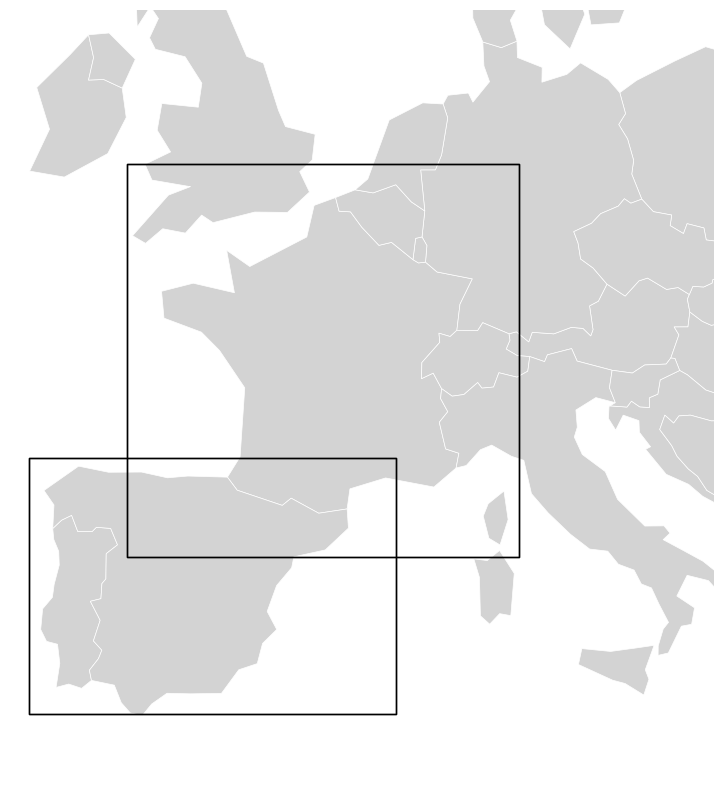

In [ ]:
box_FR = shapely.Polygon(
    [
        (-6, 41),
        (10, 41),
        (10, 52),
        (-6, 52),
        (-6, 41),
    ]
)
box_ES = shapely.Polygon(
    [
        (-10, 36),
        (5, 36),
        (5, 44),
        (-10, 44),
        (-10, 36),
    ]
)
# Create geopandas picture
geodf = gpd.GeoDataFrame(
    {
        "name": ["FR", "ES"],
        "geometry": [box_FR, box_ES],
    },
    crs="EPSG:4326",
)

geodf_proj = geodf.to_crs(epsg=3857)
ax = geodf_proj.plot(edgecolor="black", facecolor="none", figsize=(10, 10))
fig = ax.get_figure()

# Load built-in Natural Earth low-resolution world map
# Natural Earth countries
url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(url)

# Select Europe
europe = world[world["CONTINENT"] == "Europe"]

# Reproject to match your map
europe_proj = europe.to_crs(epsg=3857)

# Plot background
europe_proj.plot(
    ax=ax,
    color="lightgray",
    edgecolor="white",
    linewidth=0.5,
    zorder=0,
)

# Put your geometry on top
geodf_proj.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    zorder=1,
)
# Optional zoom around France/Spain
ax.set_xlim(-1.2e6, 2.0e6)
ax.set_ylim(4.0e6, 7.5e6)

ax.set_axis_off()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
fig.savefig(f"../reports/figures/weather_grids.pdf", bbox_inches="tight")
plt.show()

### River data France

In [ ]:
river_names = [
    "La Seine",
    "La Garonne",
    "la Loire",
    "La Moselle",
    "La Meuse",
    "Le Rhône",
    "Le Rhin",
    "la Vienne",
    "La Dordogne",
]
river_map = {
    "Le Rhône": "rhone",
    "La Garonne": "garonne",
    "La Dordogne": "dordogne",
    "la Vienne": "vienne",
    "la Loire": "loire",
    "Le Rhin": "rhein",
    "La Seine": "seine",
    "La Moselle": "mosel",
    "La Meuse": "maas",
}

river_selected = "rhein"


# get stations for river code

url = "https://hubeau.eaufrance.fr/api/v1/temperature/station"
all_sites_temp = []
size = 1000
page = 1
while True:
    response = requests.get(url, params={"size": size, "page": page})
    data = response.json().get("data", [])

    if not data:  # no more results
        break

    all_sites_temp.extend(data)
    print(f"Fetched page {page}, total sites so far: {len(all_sites_temp)}")
    page += 1

stations_temp = {}
for river in river_names:
    stations_river = [
        site["code_station"]
        for site in all_sites_temp
        if "libelle_cours_eau" in site and site["libelle_cours_eau"]
        if river in site["libelle_cours_eau"]
    ]
    stations_temp[river_map[river]] = stations_river


stations_temp_selected = [
    site
    for site in all_sites_temp
    if site["code_station"] in stations_temp[river_selected]
]

url = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/referentiel/sites"
all_sites = []
size = 1000
page = 1

while True:
    response = requests.get(url, params={"size": size, "page": page})
    data = response.json().get("data", [])

    if not data:  # no more results
        break

    all_sites.extend(data)
    print(f"Fetched page {page}, total sites so far: {len(all_sites)}")
    page += 1


stations_hydro = {}
for river in river_names:
    stations_river = [
        site["code_site"]
        for site in all_sites
        if "libelle_cours_eau" in site and site["libelle_cours_eau"]
        if river in site["libelle_cours_eau"]
    ]
    stations_hydro[river_map[river]] = stations_river
stations_hydro_selected = [
    site for site in all_sites if site["code_site"] in stations_hydro[river_selected]
]
print(stations_hydro_selected)
url = f"https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab?code_entite={stations_hydro[river_selected][0]}&date_debut_obs_elab={2018}-01-01&date_fin_obs_elab={2023}-01-01&size=20000"
import time

for i in range(10):
    response = requests.get(url)
    if response.status_code == 503:
        print("Server busy, retrying...")
        time.sleep(2**i)
        continue
    else:
        break

print(response)

data = response.json()
print(data)


fig, ax = plt.subplots(
    1,
    1,
)


gdf = gpd.GeoDataFrame(
    stations_temp_selected,
    geometry=gpd.points_from_xy(
        [s["longitude"] for s in stations_temp_selected],
        [s["latitude"] for s in stations_temp_selected],
    ),
    crs="EPSG:4326",
)
gdf_hydro = gpd.GeoDataFrame(
    stations_hydro_selected,
    geometry=gpd.points_from_xy(
        [s["longitude_site"] for s in stations_hydro_selected],
        [s["latitude_site"] for s in stations_hydro_selected],
    ),
    crs="EPSG:4326",
)
time = pd.Timestamp("20200101")
geo_df = load_zones(["FR"], time)
geo_df = geo_df.to_crs(gdf.crs)

gdf.plot(ax=ax, color="red")
gdf_hydro.plot(ax=ax, color="green")
gdf.plot(ax=ax, color="blue")
geo_df.boundary.plot(ax=ax)

In [23]:
import time


def get_river_temp(station, year):
    """for each station get hourly temperature data for one year






    Parameters:






        - station: code of the station






        - year: year of the data






    Returns:






        - temp_series: Series with hourly temperature data for the station"""

    url = f"https://hubeau.eaufrance.fr/api/v1/temperature/chronique?code_station={station}&date_debut_mesure={year}-01-01&date_fin_mesure={year+1}-01-01&size=20000"

    for i in range(10):
        response = requests.get(url)
        if response.status_code == 503:
            print("Server busy, retrying...")
            time.sleep(2**i)
            continue
        else:
            break

    print(response)

    data = response.json()

    if data["data"] == []:

        print(f"no data for station {station} in {year}-{year+1}")

        return None

    parameter_set = set()
    unit_set = set()
    for i in range(len(data["data"])):
        entry = data["data"][i]
        libelle_parameter = entry["libelle_parametre"]
        unit = entry["symbole_unite"]
        parameter_set.add(libelle_parameter)
        unit_set.add(unit)
    print(parameter_set)
    print(unit_set)

    df = json_normalize(data, "data")

    df["timestamp"] = pd.to_datetime(
        df["date_mesure_temp"] + df["heure_mesure_temp"], format="%Y-%m-%d%H:%M:%S"
    )

    df = df.set_index("timestamp")

    df = df.tz_localize(
        tz="Europe/Paris", nonexistent="NaT", ambiguous="NaT"
    ).tz_convert(tz="utc")

    df = df[~df.index.duplicated()]  # drop duplicated indices

    temp_series = df["resultat"].resample("1h").mean()

    temp_series.name = station
    return temp_series

In [ ]:
# calc mean river temperature for all rivers with nuclear power plants nearby

# data is often scarse e.g. for le rhone only data for 3 stations available in only 2015,2016,2023.
rivers = river_map.values()
river_temp_df = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
river_temp_df.index.name = "timestamp"

for river in rivers:
    print(river)
    frames = []
    stations = stations_temp[river]
    if stations is None:
        continue
    for year in range(2017, 2024):
        start = pd.Timestamp(f"{year}0101", tz="utc")
        end = pd.Timestamp(f"{year+1}0101", tz="utc")
        station_df = pd.DataFrame(index=pd.date_range(start, end, freq="h", tz="utc"))
        station_df.index.name = "timestamp"

        for station in stations:
            # print(year)
            s_tmp = get_river_temp(station=station, year=year)

            if s_tmp is None:
                continue
            station_df = station_df.join(s_tmp)
        frames.append(station_df)
    stations_total_time = pd.concat(frames)
    df_tmp = stations_total_time.mean(skipna=True, axis=1)
    df_tmp.name = river

    # mean temperature for each river
    river_temp_df = river_temp_df.join(df_tmp)

# mean temperature of all rivers
river_temp_mean = river_temp_df[~river_temp_df.index.duplicated()]
print(river_temp_mean.columns)
river_temp_mean = river_temp_mean.rename(columns={r: "river_temp_" + r for r in rivers})
# mean flow rate of all rivers
river_temp_mean["river_temp"] = river_temp_mean.mean(axis=1)

river_temp_mean.to_csv(paths["river_temp_FR"])

for column in river_temp_mean.columns:
    plt.plot(river_temp_mean[column].resample("1W").mean(), label=column)
# plt.ylim(0, 600)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [25]:
def get_river_flow(station_code):
    """get flow rate for one station
    Parameters:
        - station_code: code of the station
    Returns:
        - temp_series: Series with hourly flow rate data for the station
    """

    # added one year to end date to get all days of the last year
    start_year = START.year
    end_year = END.year + 1
    url = f"https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab?code_entite={station_code}&date_debut_obs_elab={start_year}-01-01&date_fin_obs_elab={end_year}-01-01&grandeur_hydro=Q&size=20000"

    for reconnecting_times in range(100):
        response = requests.get(url)
        # print(response)
        if response.status_code == 500:
            # print("sever error 500: retry ", reconnecting_times)
            time.sleep(20)
        else:
            break
    data = response.json()
    if data["data"] == []:
        # print(f"no data for station {station_code}")
        return None
    filtered_data = []
    grandeurs = set()
    for i in range(len(data["data"])):
        entry = data["data"][i]
        grandeur = entry["grandeur_hydro_elab"]
        grandeurs.add(grandeur)
        if grandeur == "QmnJ":  # Only keep mean daily flows
            filtered_data.append(entry)
    if filtered_data == []:
        # print(f"no data for station {station_code}")
        return None
    print(f"data for station {station_code}")
    # print(grandeurs)
    df = json_normalize(filtered_data)
    df["timestamp"] = pd.to_datetime(df["date_obs_elab"], format="%Y-%m-%d")
    df = df.set_index("timestamp")
    df = df.tz_localize(
        tz="Europe/Paris", nonexistent="NaT", ambiguous="NaT"
    ).tz_convert(tz="utc")
    df = df[~df.index.duplicated()]  # drop duplicated indices
    temp_series = (
        df["resultat_obs_elab"].resample("1h")
    ).ffill()  # This is fine there are no nans
    temp_series.name = station_code
    return temp_series

In [ ]:
# calc mean river temperature for all rivers with npp nearby
import time

rivers = river_map.values()
river_flow_mean = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
river_flow_mean.index.name = "timestamp"

for river in rivers:
    print(river)
    station_codes = stations_hydro[river]

    if station_codes is None:
        continue
    frames = []
    station_df = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
    station_df.index.name = "timestamp"

    for station_code in station_codes:
        s_tmp = get_river_flow(station_code=station_code)
        if s_tmp is None:
            continue
        station_df = station_df.join(s_tmp)

    df_tmp = station_df.mean(skipna=True, axis=1)
    df_tmp.name = river

    # mean flow rate of each river
    river_flow_mean = river_flow_mean.join(df_tmp)


# drop duplicated indices
river_flow_mean = river_flow_mean[~river_flow_mean.index.duplicated()]
print(river_flow_mean.columns)
river_flow_mean = river_flow_mean.rename(columns={r: "river_flow_" + r for r in rivers})
river_flow_mean = river_flow_mean / 1000  # convert to m3/s as original is l/s
# mean flow rate of all rivers
river_flow_mean["river_flow_mean"] = river_flow_mean.mean(axis=1)

river_flow_mean.to_csv(paths["river_flow_FR"])
for column in river_flow_mean.columns:
    plt.plot(river_flow_mean[column].resample("1W").mean(), label=column)
# plt.ylim(0, 600)
plt.legend()
plt.show()

### River data Spain

In [ ]:
csv_files = glob.glob(os.path.join(paths["river_temp_ES_raw"], "*.csv"))

river_data = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
river_data.index.name = "timestamp"
for file in csv_files:
    print(file)
    try:
        df = pd.read_csv(file, sep=";", skiprows=1, engine="python")
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
        if not "No hay datos con la selección efectuada" in df.columns:
            filename = os.path.basename(file)
            station_name = filename.split("_")[-1].split(".")[0]
            df = df.set_index("FECHA_GRUPO")
            df.index = pd.to_datetime(df.index, format="%d/%m/%Y").tz_localize(
                tz="Europe/Madrid", nonexistent="NaT", ambiguous="NaT"
            )
            hourly_index = pd.date_range(
                start=df.index.min(),
                end=df.index.max() + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
                freq="H",
                tz="Europe/Madrid",
            )
            # Reindex your DataFrame
            df_hourly = df.reindex(hourly_index)
            df_hourly = df_hourly.groupby(df_hourly.index.date).ffill()
            df_hourly = df_hourly.tz_convert("utc")
            river_data[station_name] = df_hourly["MEDIA (oC)"]
        else:
            print("no data in file")
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {file}")
river_data["river_temp"] = river_data.mean(axis=1, skipna=True)
river_data = river_data[["river_temp"]]
river_data.to_csv(paths["river_temp_ES"])

In [ ]:
# Exclude reservoir and canal
excluded_stations = [
    "A161L67QRIO2",  # Caudal Total ebro en Palazuelos (Rio + Canal)
    "A333L66QRIO2",  # Caudal Ebro Riosequillo-Iber (Embalse)
]

csv_files = glob.glob(os.path.join(paths["river_flow_ES_raw"], "*.csv"))
river_data = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))
river_data.index.name = "timestamp"
for file in csv_files:
    print(file)
    try:
        df = pd.read_csv(file, sep=";", skiprows=1, engine="python")
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
        if not "No hay datos con la selección efectuada" in df.columns:
            filename = os.path.basename(file)
            station_name = filename.split("_")[-1].split(".")[0]
            if station_name not in excluded_stations:
                df = df.set_index("FECHA_GRUPO")
                df.index = pd.to_datetime(df.index, format="%d/%m/%Y").tz_localize(
                    tz="Europe/Madrid", nonexistent="NaT", ambiguous="NaT"
                )
                hourly_index = pd.date_range(
                    start=df.index.min(),
                    end=df.index.max() + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
                    freq="h",
                    tz="Europe/Madrid",
                )
                # Reindex your DataFrame
                df_hourly = df.reindex(hourly_index)
                df_hourly = df_hourly.groupby(df_hourly.index.date).ffill()
                df_hourly = df_hourly.tz_convert("utc")
                river_data[station_name] = df_hourly["MEDIA (m3/s)"]
        else:
            print("no data in file")
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {file}")
river_data["river_flow_mean"] = river_data.mean(axis=1, skipna=True)
river_data = river_data[["river_flow_mean"]]
river_data.to_csv(paths["river_flow_ES"])

### Public holidays

In [33]:
# data from https://www.data.gouv.fr/en/datasets/jours-feries-en-france/
holidays = pd.read_csv(paths["FR_holiday_raw"])
holidays = holidays[
    holidays["zones"]
    == "Métropole|Alsace-Moselle|Guadeloupe|Guyane|Martinique|Mayotte|Nouvelle-Calédonie|La Réunion|Polynésie Française|Saint-Barthélémy|Saint-Martin|Wallis-et-Futuna|Saint-Pierre-et-Miquelon"
]
holidays["timestamp"] = pd.to_datetime(holidays["date"]).dt.tz_localize(tz="utc")
holidays = holidays.drop("date", axis=1).set_index("timestamp")
holidays = holidays.loc[START:END]
holidays.to_csv(paths["FR_holiday"])

In [34]:
holidays_ES = pd.read_excel(paths["ES_holiday_raw"], skiprows=6)
holidays_ES = holidays_ES.rename(columns={"Day": "timestamp"}).set_index("timestamp")
holidays_ES.index = pd.to_datetime(holidays_ES.index).tz_localize("Europe/Madrid")

holidays_FR = (
    pd.read_csv(paths["FR_holiday"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .tz_convert("Europe/Paris")
)


# Define start and end limits
start_date = START.tz_convert("Europe/Madrid") - pd.Timedelta(
    days=1
)  # include first day
end_date = END.tz_convert("Europe/Madrid")


# Create a DataFrame with all hours in the time range
calendrical_data = pd.DataFrame(
    index=pd.date_range(start_date, end_date, freq="h")
).tz_convert("Europe/Madrid")
calendrical_data.index.name = "timestamp"
calendrical_data["day"] = calendrical_data.index.weekday


# Define Isworkingday for FR
calendrical_data["isworkingday_FR"] = calendrical_data["day"].apply(
    lambda x: False if x in [5, 6] else True
)
calendrical_data.loc[holidays_FR.index, "isworkingday_FR"] = False
# Group by the day and apply the condition
calendrical_data["isworkingday_FR"] = calendrical_data.groupby(
    calendrical_data.index.date
)["isworkingday_FR"].transform(lambda x: all(x))

# Define Isworkingday for ES
calendrical_data["isworkingday_ES"] = calendrical_data["day"].apply(
    lambda x: False if x in [5, 6] else True
)
calendrical_data.loc[holidays_ES.index, "isworkingday_ES"] = False
# Group by the day and apply the condition
calendrical_data["isworkingday_ES"] = calendrical_data.groupby(
    calendrical_data.index.date
)["isworkingday_ES"].transform(lambda x: all(x))


calendrical_data["year"] = calendrical_data.index.year
calendrical_data["day_of_year"] = calendrical_data.index.dayofyear
calendrical_data["month"] = calendrical_data.index.month
calendrical_data["hour"] = calendrical_data.index.hour

calendrical_data.index = calendrical_data.index.tz_convert("UTC")

calendrical_data = calendrical_data.truncate(before=START, after=END)
calendrical_data.to_csv(paths["calendrical_data"])

## Merge all data into one df

In [ ]:
def read_generation(path, country_code):
    """read generation data from csv file and rename columns to match the column names in the database
    unnessecary complicated because some bidding zone have multiindex and others not
    Parameters:
        -path: path to the csv file
    Returns:
        - generation: DataFrame with generation data
    """

    # test read file to check if multi index, disable warnings for test read

    with warnings.catch_warnings():

        warnings.simplefilter("ignore")

        test = pd.read_csv(path, nrows=3)

        is_multi_idx = (
            type(test.iloc[0, 1]) == str
        )  # pick first element and chekc if string.

    if is_multi_idx:

        generation = pd.read_csv(path, header=[0, 1]).rename(
            columns={"Unnamed: 0_level_0": "timestamp", "Unnamed: 0_level_1": ""}
        )

        generation["timestamp"] = pd.to_datetime(generation["timestamp"], utc=True)

        generation = generation.set_index("timestamp")

        generation.columns = [
            GEN_COLUMN_MAP[" ".join(col).strip()] for col in generation.columns.values
        ]
    else:

        generation = pd.read_csv(path, header=[0]).rename(
            columns={"Unnamed: 0": "timestamp"}
        )

        generation["timestamp"] = pd.to_datetime(generation["timestamp"], utc=True)

        generation = generation.set_index("timestamp").rename(
            columns=GEN_COLUMN_MAP_ALT
        )

        # generation.columns = [GEN_COLUMN_MAP_ALT[' '.join(col).strip()] for col in generation.columns.values]
    generation = generation.rename(columns=lambda x: x + "_" + country_code)
    return generation

In [ ]:
# load all data and merge into one dataframe
european_prices_da = pd.read_csv(
    paths["european_prices_da"], parse_dates=["timestamp"]
).set_index("timestamp")
european_prices_da = european_prices_da.rename(
    columns={x: "price_da_" + x for x in european_prices_da.columns}
)

carbon_price = pd.read_csv(paths["carbon_price"], parse_dates=["timestamp"]).set_index(
    "timestamp"
)


gas_price = pd.read_csv(paths["gas_price"], parse_dates=["timestamp"]).set_index(
    "timestamp"
)


res_load_da = pd.read_csv(paths["res_load_da"], parse_dates=["timestamp"]).set_index(
    "timestamp"
)


res_load_da = res_load_da.truncate(after=END)


# Files for individual countries


net_export_FR = (
    pd.read_csv(paths["net_export_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={cc: "FR" + "->" + cc for cc in NEIGHBOURS["FR"]})
    .rename(columns={"agg_net_export": "net_export_FR"})
)


net_export_ES = (
    pd.read_csv(paths["net_export_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={cc: "ES" + "->" + cc for cc in NEIGHBOURS["ES"] + ["MA", "AD"]})
    .rename(
        columns={
            "agg_net_export": "net_export_ES",
            "agg_net_export_MA": "net_export_ES_MA",
        }
    )
)


renew_FR = (
    pd.read_csv(paths["renew_FR"])
    .set_index("timestamp")
    .rename(columns=lambda x: x + "_" + "FR")
)


renew_ES = (
    pd.read_csv(paths["renew_ES"])
    .set_index("timestamp")
    .rename(columns=lambda x: x + "_" + "ES")
)

load_da_FR = (
    pd.read_csv(paths["load_da_FR"])
    .rename(columns={"load_da": "load_da_FR"})
    .set_index("timestamp")
)


load_da_ES = (
    pd.read_csv(paths["load_da_ES"])
    .rename(columns={"load_da": "load_da_ES"})
    .set_index("timestamp")
)


generation_FR = read_generation(paths["generation_FR"], "FR")


generation_ES = read_generation(paths["generation_ES"], "ES")


print(generation_FR.isna().sum())


na_rte_FR = pd.read_csv(paths["na_rte_FR"], parse_dates=["timestamp"]).set_index(
    "timestamp"
)
na_rte_FR = na_rte_FR.rename(
    columns={col: col + "_rte_FR" for col in na_rte_FR.columns}
)
na_rte_FR = na_rte_FR[["nuclear_avail_rte_FR", "nuclear_avail_unplanned_rte_FR"]]


na_esio_ES = pd.read_csv(paths["na_esios_ES"], parse_dates=["timestamp"]).set_index(
    "timestamp"
)
na_esio_ES = na_esio_ES.rename(
    columns={col: col + "_esios_ES" for col in na_esio_ES.columns}
)

filling_rate_FR = (
    pd.read_csv(paths["filling_rate_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"filling_rate": "filling_rate_FR"})
)
filling_rate_ES = (
    pd.read_csv(paths["filling_rate_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"filling_rate": "filling_rate_ES"})
)

river_temp_FR = (
    pd.read_csv(paths["river_temp_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"river_temp": "river_temp_FR"})
)


river_temp_ES = (
    pd.read_csv(paths["river_temp_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"river_temp": "river_temp_ES"})
)


river_flow_FR = (
    pd.read_csv(paths["river_flow_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"river_flow_mean": "river_flow_mean_FR"})
)


river_flow_ES = (
    pd.read_csv(paths["river_flow_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"river_flow_mean": "river_flow_mean_ES"})
)

wind_era5_FR = (
    pd.read_csv(paths["era5_wind_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"100m_wind_speed": "wind_speed_100m_FR"})[["wind_speed_100m_FR"]]
)
wind_era5_ES = (
    pd.read_csv(paths["era5_wind_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"100m_wind_speed": "wind_speed_100m_ES"})[["wind_speed_100m_ES"]]
)
solar_era5_FR = (
    pd.read_csv(paths["era5_solar_temp_FR"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"ssrd": "ssrd_FR", "t2m": "air_temp_era5_FR"})
)
solar_era5_ES = (
    pd.read_csv(paths["era5_solar_temp_ES"], parse_dates=["timestamp"])
    .set_index("timestamp")
    .rename(columns={"ssrd": "ssrd_ES", "t2m": "air_temp_era5_ES"})
)

load_renewables_FR = renew_FR.join(load_da_FR)
load_renewables_FR.index = pd.to_datetime(load_renewables_FR.index, utc="utc")


load_renewables_ES = renew_ES.join(load_da_ES)
load_renewables_ES.index = pd.to_datetime(load_renewables_ES.index, utc="utc")

In [ ]:
data_scm = pd.DataFrame(index=pd.date_range(START, END, freq="h", tz="utc"))


data_scm.index.name = "timestamp"


data_scm = (
    data_scm.join(european_prices_da)
    .join(carbon_price)
    .join(gas_price)
    .join(res_load_da)
    .join(load_renewables_FR)
    .join(generation_FR)
    .join(filling_rate_FR)
    .join(river_temp_FR)
    .join(river_flow_FR)
    .join(net_export_FR)
    .join(load_renewables_ES)
    .join(generation_ES)
    .join(filling_rate_ES)
    .join(river_temp_ES)
    .join(river_flow_ES)
    .join(net_export_ES)
    .join(wind_era5_FR)
    .join(wind_era5_ES)
    .join(solar_era5_FR)
    .join(solar_era5_ES)
    .join(na_rte_FR)
    .join(na_esio_ES)
)

calendrical_data = pd.read_csv(
    paths["calendrical_data"], parse_dates=["timestamp"]
).set_index("timestamp")
data_scm = data_scm.join(calendrical_data)


# aggregate da wind
data_scm["wind_da_ES"] = data_scm.get("wind_on_da_ES", 0) + data_scm.get(
    "wind_off_da_ES", 0
)
data_scm["wind_cap_ES"] = data_scm.get("wind_cap_on_ES", 0) + data_scm.get(
    "wind_cap_off_ES", 0
)

total_wind_da_FR = data_scm["wind_on_da_FR"].fillna(0) + data_scm[
    "wind_off_da_FR"
].fillna(0)

total_wind_da_FR.loc[
    (data_scm["wind_on_da_FR"].isna()) & (data_scm["wind_off_da_FR"].isna())
] = np.nan
data_scm["wind_da_FR"] = total_wind_da_FR
data_scm["wind_cap_FR"] = data_scm.get("wind_cap_on_FR", 0) + data_scm.get(
    "wind_cap_off_FR", 0
)


# convert hour, season to cyclical value for linear regression
data_scm.loc[:, "hour_sin"] = np.sin(data_scm.loc[:, "hour"] * (2.0 * np.pi / 24))
data_scm.loc[:, "hour_cos"] = np.cos(data_scm.loc[:, "hour"] * (2.0 * np.pi / 24))
data_scm.loc[:, "day_of_year_sin"] = np.sin(
    (data_scm.loc[:, "day_of_year"] - 1) * (2.0 * np.pi / 365)
)
data_scm.loc[:, "day_of_year_cos"] = np.cos(
    (data_scm.loc[:, "day_of_year"] - 1) * (2.0 * np.pi / 365)
)
data_scm = data_scm.truncate(after=END)
data_scm = data_scm.truncate(before=START)


print(data_scm.isna().sum())
data_scm.to_csv(paths["data_full"])

In [ ]:
# data used for causal inference project
data_selected = data_scm[
    [
        "rl_DE_LU",
        "rl_ES",
        "rl_FR",
        "rl_BE",
        "rl_IT_NORD",
        "rl_PT",
        "price_da_FR",
        "price_da_ES",
        "net_export_FR",
        "net_export_ES",
        "net_export_ES_MA",
        "carbon_price_FR",
        "carbon_price_ES",
        "gas_price_FR",
        "gas_price_ES",
        "gas_price_MIBGAS",
        "load_da_FR",
        "load_da_ES",
        "wind_da_FR",
        "wind_da_ES",
        "solar_da_FR",
        "solar_da_ES",
        "nuclear_avail_rte_FR",
        "nuclear_avail_esios_ES",
        "run_off_gen_FR",
        "run_off_gen_ES",
        "filling_rate_FR",
        "filling_rate_ES",
        "hydro_reservoir_gen_FR",
        "hydro_reservoir_gen_ES",
        "wind_speed_100m_FR",
        "wind_speed_100m_ES",
        "ssrd_FR",
        "ssrd_ES",
        "air_temp_era5_FR",
        "air_temp_era5_ES",
        "river_temp_FR",
        "river_temp_ES",
        "river_flow_mean_FR",
        "river_flow_mean_ES",
        "isworkingday_FR",
        "isworkingday_ES",
        "hour_sin",
        "hour_cos",
        "day_of_year_sin",
        "day_of_year_cos",
        "year",
    ]
]
print(data_selected.isna().sum()[0:60])
data_selected.to_csv(paths["data_selected"])